In [ ]:
#single core

from skmultilearn.model_selection import iterative_train_test_split
import numpy as np
import pandas as pd
import os
import math
from joblib import Parallel, delayed

# 路径
label_dir = '/home/mtang/vslib/mlpc2025_Team_Laborer/MLPC2025_classification/labels'
split_csv = '/home/mtang/vslib/mlpc2025_Team_Laborer/notebooks/Task3/tang/data_split_tang.csv'

# 读文件列表
files = pd.read_csv(split_csv)['filename'].tolist()
classes = list(np.load(os.path.join(label_dir, files[0].replace('.mp3','_labels.npz'))).keys())

# 1) 构造 X_files, y_files，按文件一级聚合
X_files = np.arange(len(files)).reshape(-1,1)  # dummy features
y_list  = []
blank_rates = []

for fn in files:
    labs = np.load(os.path.join(label_dir, fn.replace('.mp3','_labels.npz')))
    # 生成文件级的多标签：该类别是否出现过
    y_file = [(labs[c].sum(axis=1) >= math.ceil(labs[c].shape[1]/2)).any() for c in classes]
    # 计算空白帧比例
    total_frames = next(iter(labs.values())).shape[0]
    nonzero = sum((labs[c].sum(axis=1) >= math.ceil(labs[c].shape[1]/2)).sum()
                  for c in classes)
    blank_rate = 1 - nonzero/ total_frames
    y_list.append(y_file)
    blank_rates.append(blank_rate)

y_files = np.array(y_list, dtype=int)

# 2) 对 blank_rate 做分箱（例如 4 段）
bins = pd.qcut(blank_rates, q=4, labels=False)  # 0,1,2,3
onehot = np.eye(4)[bins]                       # (n_files,4)

# 3) 拼接到 y_files 后面，形成新的多标签矩阵
y_aug = np.hstack([y_files, onehot])

# 4) 分层划分：先 train/(val+test)
X_train, y_train, X_tmp, y_tmp = \
    iterative_train_test_split(X_files, y_aug, test_size=0.30)

# 5) 再在 tmp 上一分为二，val/test 各占一半
X_val, y_val, X_test, y_test = \
    iterative_train_test_split(X_tmp, y_tmp, test_size=0.50)

# 最终 train/val/test 三部分的文件索引：
train_idx = X_train.ravel().astype(int)
val_idx   = X_val.ravel().astype(int)
test_idx  = X_test.ravel().astype(int)

train_files = [files[i] for i in train_idx]
val_files   = [files[i] for i in val_idx]
test_files  = [files[i] for i in test_idx]


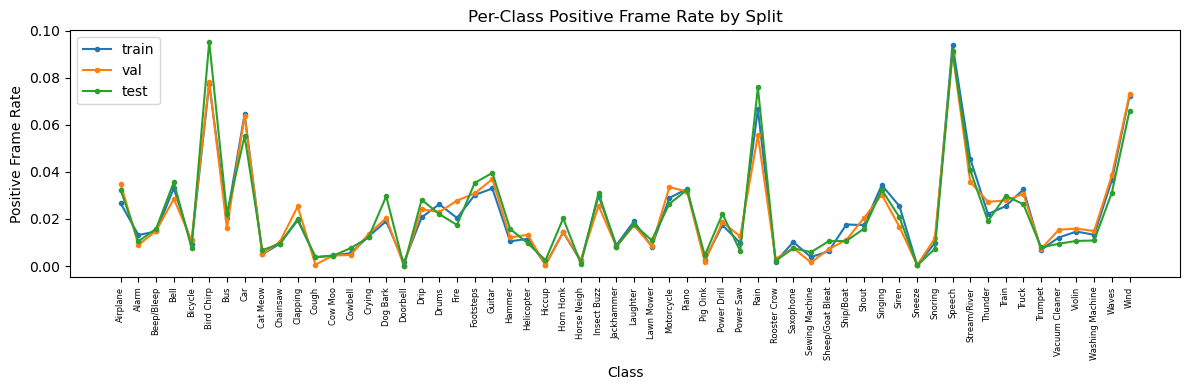

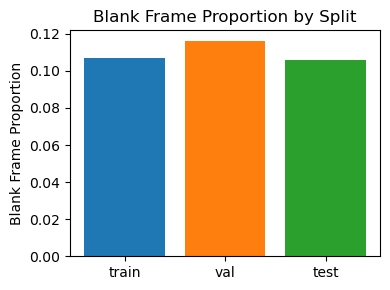

In [2]:
#results check
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# 路径设置
split_csv = '/home/mtang/vslib/mlpc2025_Team_Laborer/notebooks/Task3/tang/data_split_tang.csv'
label_dir = '/home/mtang/vslib/mlpc2025_Team_Laborer/MLPC2025_classification/labels'

# 1. 读取 train/val/test 文件列表
split_df = pd.read_csv(split_csv)
splits = {
    'train': split_df[split_df['split']=='train']['filename'].tolist(),
    'val':   split_df[split_df['split']=='val']['filename'].tolist(),
    'test':  split_df[split_df['split']=='test']['filename'].tolist()
}

# 2. 获取类别名单
first_file = splits['train'][0]
classes = list(np.load(os.path.join(label_dir, first_file.replace('.mp3','_labels.npz'))).keys())

# 3. 计算每个 split 的正帧率和空白帧率
pos_rates = {sp: np.zeros(len(classes)) for sp in splits}
blank_rates = {}

for sp, files in splits.items():
    total_frames = 0
    pos_counts = np.zeros(len(classes))
    blank_count = 0

    for fn in files:
        lab_npz = np.load(os.path.join(label_dir, fn.replace('.mp3','_labels.npz')))
        # 每帧二值化：多数投票决定
        votes = []
        for i, c in enumerate(classes):
            arr = lab_npz[c]
            mask = (arr.sum(axis=1) >= math.ceil(arr.shape[1] / 2))
            pos_counts[i] += mask.sum()
            votes.append(mask)
        votes = np.vstack(votes).T  # shape (T, n_classes)
        T = votes.shape[0]
        blank_count += np.sum(votes.sum(axis=1) == 0)
        total_frames += T

    pos_rates[sp] = pos_counts / total_frames
    blank_rates[sp] = blank_count / total_frames

# 4. 用 DataFrame 整理
df_rates = pd.DataFrame(pos_rates, index=classes)

# 5. 绘制 58 条类的正帧率曲线
plt.figure(figsize=(12,4))
for sp in df_rates.columns:
    plt.plot(df_rates.index, df_rates[sp], marker='o', markersize=3, label=sp)
plt.xticks(rotation=90, fontsize=6)
plt.xlabel('Class')
plt.ylabel('Positive Frame Rate')
plt.title('Per-Class Positive Frame Rate by Split')
plt.legend()
plt.tight_layout()
plt.show()

# 6. 绘制空白帧比例对比
plt.figure(figsize=(4,3))
plt.bar(blank_rates.keys(), blank_rates.values(), color=['C0','C1','C2'])
plt.ylabel('Blank Frame Proportion')
plt.title('Blank Frame Proportion by Split')
plt.tight_layout()
plt.show()


In [6]:
#multicore 

from skmultilearn.model_selection import iterative_train_test_split
import numpy as np
import pandas as pd
import os
import math
from joblib import Parallel, delayed

# 路径
label_dir = '/home/mtang/vslib/mlpc2025_Team_Laborer/MLPC2025_classification/labels'
split_csv = '/home/mtang/vslib/mlpc2025_Team_Laborer/notebooks/Task3/tang/data_split_tang.csv'

files = pd.read_csv(split_csv)['filename'].tolist()
classes = list(np.load(os.path.join(label_dir, files[0].replace('.mp3','_labels.npz'))).keys())

# 定义处理单个文件的函数
def process_file(fn):
    labs = np.load(os.path.join(label_dir, fn.replace('.mp3','_labels.npz')))
    # 文件级多标签
    y_file = [
        (labs[c].sum(axis=1) >= math.ceil(labs[c].shape[1]/2)).any()
        for c in classes
    ]
    # 计算空白帧比例
    total_frames = next(iter(labs.values())).shape[0]
    nonzero = sum(
        (labs[c].sum(axis=1) >= math.ceil(labs[c].shape[1]/2)).sum()
        for c in classes
    )
    blank_rate = 1 - nonzero / total_frames
    return y_file, blank_rate

# 并行跑：n_jobs=6 用 6 个进程
results = Parallel(n_jobs=10, backend='loky')(
    delayed(process_file)(fn) for fn in files
)

# 拆包
y_list, blank_rates = zip(*results)
y_files = np.array(y_list, dtype=int)

# 后面的分箱、拼接、划分就一样了
bins = pd.qcut(blank_rates, q=4, labels=False)
onehot = np.eye(4)[bins]
y_aug = np.hstack([y_files, onehot])

X_files = np.arange(len(files)).reshape(-1,1)
X_train, y_train, X_tmp, y_tmp = iterative_train_test_split(X_files, y_aug, test_size=0.30)
X_val, y_val, X_test, y_test = iterative_train_test_split(X_tmp, y_tmp, test_size=0.50)

train_idx = X_train.ravel().astype(int)
val_idx   = X_val.ravel().astype(int)
test_idx  = X_test.ravel().astype(int)

train_files = [files[i] for i in train_idx]
val_files   = [files[i] for i in val_idx]
test_files  = [files[i] for i in test_idx]
